In [ ]:
import tensorflow as tf
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
 raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


In [ ]:
# загрузка датасета
from keras.datasets import imdb
vocabulary_size = 5000
index_from = 3
(X_train, y_train), (X_test, y_test) = imdb.load_data(path="imdb.npz", num_words=vocabulary_size, skip_top=0, maxlen=None, seed=11, start_char=1, oov_char=2, index_from=index_from)

print('Shape of X train:', X_train.shape)
print('Shape of Y train:', y_train.shape)
print('Shape of X test:', X_test.shape)
print('Shape of Y test:', y_test.shape)
print(' X test:', X_test)
print(' Y test:', y_test)
print(type(X_test))
print(type(y_test))

Shape of X train: (25000,)
Shape of Y train: (25000,)
Shape of X test: (25000,)
Shape of Y test: (25000,)
 X test: [list([1, 14, 20, 152, 60, 1833, 6, 300, 158, 14, 20, 16, 6, 2, 10, 10, 13, 3874, 15, 33, 222, 1088, 234, 7, 4, 22, 71, 2, 39, 2, 300, 241, 342, 4, 226, 20, 2, 16, 448, 7, 4, 20, 5, 15, 16, 66, 6, 1235, 589, 8, 30, 6, 708, 206, 3015, 4457, 1039, 13, 447, 15, 20, 201, 5, 319, 12, 30, 276, 23, 6, 20, 15, 2488, 60, 4146, 42, 1688, 1039, 12, 209, 399, 50, 205, 4122, 9, 51, 938, 9, 582, 8, 13, 386, 25, 67, 4, 2, 20, 86, 32, 7, 98, 5, 95, 106, 14, 5, 25, 80, 124, 51, 13, 384, 10, 10, 2])
 list([1, 86, 7, 32, 57, 31, 19, 101, 1164, 2, 585, 24, 2, 42, 21, 147, 1164, 2, 304, 14, 123, 615, 4055, 62, 30, 2, 46, 7, 101, 568, 1147, 11, 4, 178, 18, 27, 4667, 5, 484, 2, 2, 23, 350, 7, 15, 29, 9, 6, 700, 274, 109, 57, 116, 1256, 966, 3104, 411, 57, 109, 943, 4, 192, 15, 2365, 2, 1388, 90, 287, 43, 89, 995, 2, 66, 26, 5, 9, 4, 2095, 4112, 11, 328, 393, 216, 23, 48, 25, 104, 4055, 9, 6, 2, 

In [ ]:
# создание словаря для перевода индексов в слова
# заргузка словаря "слово:индекс"
word_to_id = imdb.get_word_index()
# уточнение словаря
word_to_id = {key:(value + index_from) for key,value in word_to_id.items()}
word_to_id["<PAD>"] = 0
word_to_id["<START>"] = 1
word_to_id["<UNK>"] = 2
word_to_id["<UNUSED>"] = 3
# создание обратного словаря "индекс:слово"
id_to_word = {value:key for key,value in word_to_id.items()}

some_number = 11
review_as_text = ' '.join(id_to_word[id] for id in X_train[some_number])

print("Index form of review:", X_train[some_number])
print("Text form of review:", review_as_text)
print("Review lenght:", X_train[some_number])
if y_train[some_number] == 1:
  class_label = "Positive"
else:
  class_label = "Negative"
print("Review class:", y_train[some_number], f'({class_label})')


Index form of review: [1, 17, 6, 337, 7, 2127, 2, 2, 7, 4, 2392, 325, 200, 4, 2, 13, 16, 55, 4511, 8, 67, 4, 761, 5, 4, 3695, 2, 4254, 3458, 2, 18, 89, 29, 62, 1694, 349, 5, 372, 315, 6, 147, 325, 4, 785, 2634, 10, 10, 4, 22, 272, 307, 19, 257, 136, 2429, 17, 6, 810, 3370, 40, 6, 2, 2, 5, 13, 873, 76, 662, 17, 198, 2, 405, 21, 279, 2, 16, 2, 34, 2, 4, 881, 23, 6, 147, 3219, 2, 9, 138, 14, 669, 421, 40, 6, 2, 310, 7, 4, 2, 2, 10, 10, 17, 373, 17, 4, 2, 7, 2, 4254, 1540, 89, 44, 49, 4637, 15, 4, 785, 2, 71, 3657, 2, 13, 828, 2, 8, 546, 2, 1106, 338, 5, 4, 338, 789, 338, 25, 100, 82, 1261, 6, 3190, 39, 2, 2, 10, 10, 13, 286, 32, 15, 2259, 17, 4, 1375, 822, 47, 8, 140, 145, 5, 2589, 200, 41, 543, 344, 5, 704, 2, 8, 789, 1404, 7, 4, 2634, 33, 31, 213, 41, 2, 2452, 4, 2, 9, 3883, 21, 252, 1030, 8, 4585, 46, 6, 478, 2, 13, 331, 161, 391, 41, 35, 631, 2, 37, 2, 2, 5, 2, 41, 1138, 1461, 5, 2, 17, 29, 5, 4, 2634, 401, 2, 993, 1152, 13, 104, 13, 16, 424, 8, 2, 19, 41, 2, 53, 74, 68, 993, 2, 40, 6

In [ ]:
print("Max review langht:", len(max(X_train, key=len)))
print("Min review langht:", len(min(X_train, key=len)))

Max review langht: 2494
Min review langht: 11


In [ ]:
# предобработка данных
from tensorflow.keras.utils import pad_sequences
max_words = 500
X_train = pad_sequences(X_train, maxlen=max_words, value=0, padding='pre', truncating='post')


In [ ]:
print("Max review langht:", len(max(X_train, key=len)))
print("Min review langht:", len(min(X_train, key=len)))

Max review langht: 500
Min review langht: 500


In [ ]:
# создание словаря для перевода индексов в слова
# заргузка словаря "слово:индекс"
word_to_id = imdb.get_word_index()
# уточнение словаря
word_to_id = {key:(value + index_from) for key,value in word_to_id.items()}
word_to_id["<PAD>"] = 0
word_to_id["<START>"] = 1
word_to_id["<UNK>"] = 2
word_to_id["<UNUSED>"] = 3
# создание обратного словаря "индекс:слово"
id_to_word = {value:key for key,value in word_to_id.items()}

some_number = 11
review_as_text = ' '.join(id_to_word[id] for id in X_train[some_number])

print("Index form of review:", X_train[some_number])
print("Text form of review:", review_as_text)
print("Review lenght:", X_train[some_number])
if y_train[some_number] == 1:
  class_label = "Positive"
else:
  class_label = "Negative"
print("Review class:", y_train[some_number], f'({class_label})')

Index form of review: [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    1
   17    6  337    7 2127    2    2    7    4 2392  325  200    4    2
   13   16   55 4511    8   67    4  761    5    4 3695    2 4254 3458
    2   18   89   29   62 1694  349    5  372  315    6  147  325    4
  785 2634   10   10    4   22  272  307   19  257  136 2429   17    6
  810 3370   40    6    2    2    5   13  873   76  662

In [ ]:
print('X train:', X_train)
print('Shape of X train:', X_train.shape)
print('X test:', X_test)
print('Shape of X test:', X_test.shape)

X train: [[   0    0    0 ...    6    2    2]
 [   0    0    0 ...   10   10    2]
 [   1   14   22 ...  171  153  303]
 ...
 [   0    0    0 ...   17 2199 1262]
 [   0    0    0 ...  606    5 1356]
 [   0    0    0 ... 1026    5  804]]
Shape of X train: (25000, 500)
X test: [list([1, 14, 20, 152, 60, 1833, 6, 300, 158, 14, 20, 16, 6, 2, 10, 10, 13, 3874, 15, 33, 222, 1088, 234, 7, 4, 22, 71, 2, 39, 2, 300, 241, 342, 4, 226, 20, 2, 16, 448, 7, 4, 20, 5, 15, 16, 66, 6, 1235, 589, 8, 30, 6, 708, 206, 3015, 4457, 1039, 13, 447, 15, 20, 201, 5, 319, 12, 30, 276, 23, 6, 20, 15, 2488, 60, 4146, 42, 1688, 1039, 12, 209, 399, 50, 205, 4122, 9, 51, 938, 9, 582, 8, 13, 386, 25, 67, 4, 2, 20, 86, 32, 7, 98, 5, 95, 106, 14, 5, 25, 80, 124, 51, 13, 384, 10, 10, 2])
 list([1, 86, 7, 32, 57, 31, 19, 101, 1164, 2, 585, 24, 2, 42, 21, 147, 1164, 2, 304, 14, 123, 615, 4055, 62, 30, 2, 46, 7, 101, 568, 1147, 11, 4, 178, 18, 27, 4667, 5, 484, 2, 2, 23, 350, 7, 15, 29, 9, 6, 700, 274, 109, 57, 116, 1256, 9

In [ ]:
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dropout, Dense
model = Sequential()
model.add(Embedding(input_dim=len(word_to_id), output_dim=32, input_length=500))
model.add(LSTM(units=90))
model.add(Dropout (rate=0.4))
model.add(Dense(units=1, activation='sigmoid'))
# компилируем модель
model.compile(loss='binary_crossentropy', optimizer= 'adam', metrics=['accuracy'])
#Обучаем модель
H = model.fit(X_train, y_train, validation_split=0.1, epochs=5, batch_size=32)
#вывод информации об архитектуре модели
print(model.summary())

Epoch 1/5


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.6793 - loss: 0.5783 - val_accuracy: 0.8340 - val_loss: 0.3902
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.8563 - loss: 0.3490 - val_accuracy: 0.8496 - val_loss: 0.3635
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.8929 - loss: 0.2767 - val_accuracy: 0.8764 - val_loss: 0.3063
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.9109 - loss: 0.2345 - val_accuracy: 0.8444 - val_loss: 0.3685
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.8595 - loss: 0.3257 - val_accuracy: 0.8624 - val_loss: 0.3523


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ (None, 500, 32)             │       2,834,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 90)                  │          44,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 90)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              91 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,637,563 (32.95 MB)

 Trainable params: 2,879,187 (10.98 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,758,376 (21.97 MB)

None


In [ ]:
from sklearn.metrics import classification_report
import numpy as np
X_test = pad_sequences(X_test, maxlen=max_words, value=0, padding='pre', truncating='post')
scores = model.evaluate(X_test, y_test)
print ("Loss on test data:",  scores [0])
print("Accuracy on test data:", scores [1])

test_result = model.predict(X_test)
predicted_labels = [1 if test_result[i,0]>=0.5 else 0
                    for i in range(len(test_result))]
from sklearn.metrics import classification_report
print(classification_report(y_test, predicted_labels, labels = [0, 1], target_names=['Negative', 'Positive']))

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8578 - loss: 0.3733
Loss on test data: 0.37356844544410706
Accuracy on test data: 0.8576400279998779
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step
              precision    recall  f1-score   support

    Negative       0.87      0.84      0.86     12500
    Positive       0.85      0.87      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



In [ ]:
X_test = pad_sequences(X_test, maxlen=max_words, value=0, padding='pre', truncating='post')
y_score = model.predict(X_test)
y_pred = [1 if y_score[i,0]>=0.5 else 0 for i in range(len(y_score))]
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, labels = [0, 1], target_names=['Negative', 'Positive']))

782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step
              precision    recall  f1-score   support

    Negative       0.87      0.84      0.86     12500
    Positive       0.85      0.87      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



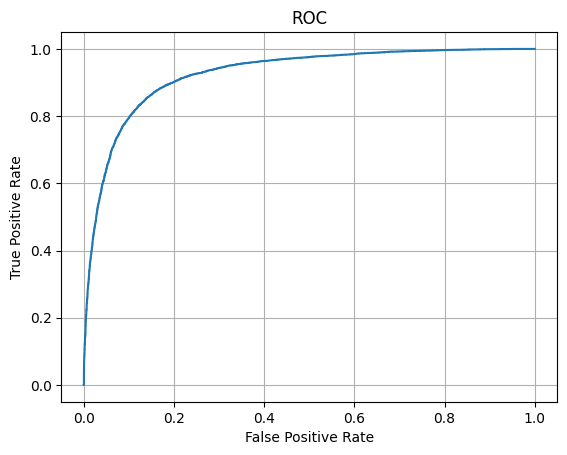

Area under ROC is 0.9259368544000001


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
fpr, tpr, thresholds = roc_curve(y_test, y_score)
plt.plot(fpr, tpr)
plt.grid()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC')
plt.show()
print('Area under ROC is', auc(fpr, tpr))

In [ ]:
from sklearn.metrics import roc_auc_score
print('AUC ROC:', roc_auc_score(y_test, y_score))

AUC ROC: 0.9259368544000001
